In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium

print('Librerias cargadas correctamente')
print(f'Version de pandas: {pd.__version__}')
print(f'Version de numpy: {np.__version__}')
print(f'Version de folium: {folium.__version__}')

Librerias cargadas correctamente
Version de pandas: 2.2.2
Version de numpy: 2.0.2
Version de folium: 0.20.0


# 2. Carga de datos


*   Carga de base de datos IPASH Suelo
*   Carga de base de datos IPASH Agua
*   Carga de base de datos IPASH Sedimento
*   Carga de normativas
*   Carga de datos para cobertura vegetal: MapBiomas + GEE (NDVI)







In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#Componente suelo:
#URL de exportación: https://docs.google.com/spreadsheets/d/17zSeu4qP2TIJK7dy0MWKBqZOAkq24xCq/edit?usp=drive_link&ouid=110342148515634196231&rtpof=true&sd=true
URL_SUELO = 'https://docs.google.com/spreadsheets/d/17zSeu4qP2TIJK7dy0MWKBqZOAkq24xCq/export?format=xlsx'
suelo = pd.read_excel(URL_SUELO)
suelo.head()

,Número de informe,Nombre de la Evaluación,Etapa,Componente ambiental,Procedencia de la Muestra,Procedencia Especifica de la Muestra,Nombre del punto,Este,Norte,Altitud,...,Descripción de ubicación,Tipo de muestra,Tipo de análisis,Etapa de extracción secuencial,Caracterización de la muestra,Fecha,Hora,Valor,Parámetro,Unidad de medida
0,INFORME N° 00003-2017-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Primer monitoreo,Suelo,Suelo,Área de potencial interés,F05447-SU01,478216,9526380,275,...,Muestra puntual de suelo tomada a 1.3 m en dir...,Simple,No aplica,No aplica,Ensayo por cromatografía - HTP,11/7/17,11:12:00 AM,514,Fracciones de Hidrocarburos F2 (C10-C28),mg/Kg
1,INFORME N° 00003-2017-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Primer monitoreo,Suelo,Suelo,Área de potencial interés,F05447-SU01,478216,9526380,275,...,Muestra puntual de suelo tomada a 1.3 m en dir...,Simple,No aplica,No aplica,Ensayo por cromatografía - HTP,11/7/17,11:12:00 AM,3795,Fracciones de Hidrocarburos F3 (C28-C40),mg/Kg
2,INFORME N° 00003-2017-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Primer monitoreo,Suelo,Suelo,Área de potencial interés,F05447-SU01,478216,9526380,275,...,Muestra puntual de suelo tomada a 1.3 m en dir...,Simple,No aplica,No aplica,Ensayo por cromatografía - HTP,11/7/17,11:12:00 AM,<0.3,Fracción de Hidrocarburos F1 (C5-C10),mg/Kg
3,INFORME N° 00003-2017-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Primer monitoreo,Suelo,Suelo,Área de potencial interés,F05447-SU01,478216,9526380,275,...,Muestra puntual de suelo tomada a 1.3 m en dir...,Simple,No aplica,No aplica,Ensayo por cromatografía - HTP,11/7/17,11:12:00 AM,4310,Hidrocarburos totales de petróleo (C5-C40),mg/Kg
4,INFORME N° 00003-2017-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Primer monitoreo,Suelo,Suelo,Área de potencial interés,F05447-SU02,478224,9526389,275,...,Muestra puntual de suelo tomada a 8.4 m en dir...,Simple,No aplica,No aplica,Ensayo por cromatografía - HTP,11/7/17,11:21:00 AM,<5.00,Fracciones de Hidrocarburos F2 (C10-C28),mg/Kg


In [5]:
#Componente agua
#URL de exportación: https://docs.google.com/spreadsheets/d/1sf285A4XFBtwktd6E2X1ZmDnr1OJaTv6/edit?usp=drive_link&ouid=110342148515634196231&rtpof=true&sd=true
URL_AGUA = 'https://docs.google.com/spreadsheets/d/1sf285A4XFBtwktd6E2X1ZmDnr1OJaTv6/export?format=xlsx'
agua = pd.read_excel(URL_AGUA)
agua.head()

,Número de informe,Nombre de la Evaluación,Etapa,Componente ambiental,Procedencia de la Muestra,Procedencia Especifica de la Muestra,Nombre del punto,Este,Norte,Altitud,Zona,Datum,Descripción de ubicación,Tipo de muestra,Tipo de análisis,Fecha,Hora,Valor,Parámetro,Unidad de medida
0,INFORME N° 00055-2019-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Segundo monitoreo,Agua,Agua natural superficial,Agua superficial de río,F01861-AG01,601347,9506175,76,18,WGS84,Punto ubicado en el río Tigre a 9 m de la oril...,Simple,Fisico Químicos,1/14/19,5:54:00 PM,<0.100,Aceites y grasas,mg/L
1,INFORME N° 00055-2019-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Segundo monitoreo,Agua,Agua natural superficial,Agua superficial de río,F01861-AG01,601347,9506175,76,18,WGS84,Punto ubicado en el río Tigre a 9 m de la oril...,Simple,Aniones por Cromatografía Iónica,1/14/19,5:54:00 PM,"0,233",Cloruros,mg/L
2,INFORME N° 00055-2019-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Segundo monitoreo,Agua,Agua natural superficial,Agua superficial de río,F01861-AG01,601347,9506175,76,18,WGS84,Punto ubicado en el río Tigre a 9 m de la oril...,Simple,Ensayo por cromatografía - PAHS,1/14/19,5:54:00 PM,<0.000013,Acenafteno,mg/L
3,INFORME N° 00055-2019-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Segundo monitoreo,Agua,Agua natural superficial,Agua superficial de río,F01861-AG01,601347,9506175,76,18,WGS84,Punto ubicado en el río Tigre a 9 m de la oril...,Simple,Ensayo por cromatografía - PAHS,1/14/19,5:54:00 PM,<0.000013,Acenaftileno,mg/L
4,INFORME N° 00055-2019-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Segundo monitoreo,Agua,Agua natural superficial,Agua superficial de río,F01861-AG01,601347,9506175,76,18,WGS84,Punto ubicado en el río Tigre a 9 m de la oril...,Simple,Ensayo por cromatografía - PAHS,1/14/19,5:54:00 PM,<0.000016,Antraceno,mg/L


In [6]:
#Componente sedimento
#URL de exportación: https://docs.google.com/spreadsheets/d/1QguQUQ66N5LRcYsGiQuEwuIf9XOrxTbF/edit?usp=drive_link&ouid=110342148515634196231&rtpof=true&sd=true
import warnings
warnings.filterwarnings('ignore')
URL_SEDIMENTO = 'https://docs.google.com/spreadsheets/d/1QguQUQ66N5LRcYsGiQuEwuIf9XOrxTbF/export?format=xlsx'
sedimento = pd.read_excel(URL_SEDIMENTO)
sedimento.head()


,Número de informe,Nombre de la Evaluación,Etapa,Componente ambiental,Procedencia de la Muestra,Procedencia Especifica de la Muestra,Nombre del punto,Este,Norte,Altitud,...,Datum,Descripción de ubicación,Tipo de muestra,Tipo de análisis,Etapa de extracción secuencial,Fecha,Hora,Valor,Parámetro,Unidad de medida
0,INFORME N° 00580-2019-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Primer monitoreo,Sedimento,Sedimento continental,Área de potencial interés,F05898_SD01,468461,9507737,0,...,WGS 84,Muestra puntual de sedimentos tomada a 4m en d...,Simple,Ensayo por cromatografía - HTP,No aplica,10/6/19,10:07:00,<1.9,Fracciones de Hidrocarburos F1 (C6-C10),mg/Kg
1,INFORME N° 00580-2019-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Primer monitoreo,Sedimento,Sedimento continental,Área de potencial interés,F05898_SD01,468461,9507737,0,...,WGS 84,Muestra puntual de sedimentos tomada a 4m en d...,Simple,Ensayo por cromatografía - HTP,No aplica,10/6/19,10:07:00,<6.8,Fracciones de Hidrocarburos F2 (C10-C28),mg/Kg
2,INFORME N° 00580-2019-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Primer monitoreo,Sedimento,Sedimento continental,Área de potencial interés,F05898_SD01,468461,9507737,0,...,WGS 84,Muestra puntual de sedimentos tomada a 4m en d...,Simple,Ensayo por cromatografía - HTP,No aplica,10/6/19,10:07:00,<6.8,Fracciones de Hidrocarburos F3 (C28-C40),mg/Kg
3,INFORME N° 00580-2019-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Primer monitoreo,Sedimento,Sedimento continental,Área de potencial interés,F05898_SD01,468461,9507737,0,...,WGS 84,Muestra puntual de sedimentos tomada a 4m en d...,Simple,Ensayo por cromatografía - PAHS,No aplica,10/6/19,10:07:00,<0.0054,Acenafteno,mg/Kg
4,INFORME N° 00580-2019-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Primer monitoreo,Sedimento,Sedimento continental,Área de potencial interés,F05898_SD01,468461,9507737,0,...,WGS 84,Muestra puntual de sedimentos tomada a 4m en d...,Simple,Ensayo por cromatografía - PAHS,No aplica,10/6/19,10:07:00,<0.0054,Acenaftileno,mg/Kg


## Carga de Normativas Ambientales

Para la evaluación del cumplimiento ambiental en las distintas matrices de estudio (agua, suelo y sedimentos) se consideraron normativas vigentes tanto en Perú como en Argentina.
En el caso de **Perú**, se trabajó con los *Estándares de Calidad Ambiental* (ECA) para agua y suelo (Decretos Supremos N° 004-2017-MINAM y N° 011-2017-MINAM, respectivamente), así como con los *Límites Máximos Permisibles* (LMP) aplicables a efluentes líquidos.

Para **Argentina**, la normativa ambiental utilizada como referencia (Ley Nacional de Residuos Peligrosos N°24.051 y su Decreto Reglamentario N°831/93), no establece límites de calidad explícitos por matriz de la misma manera que los ECA en Perú. Sin embargo, presenta criterios para la identificación y gestión de residuos peligrosos, incluyendo concentraciones de referencia para ciertos contaminantes.
Dado que estos valores no constituyen estándares de calidad ambiental directamente comparables, en el presente trabajo se emprlean como referencia complementaria, junto con criterios técnico-interpretativos y valores guía utilizados en la práctica, a fin de evaluar el grado de contaminación y permitir una comparación entre ambos marcos regulatorios.

- Normativa para Suelo (Perú): https://sinia.minam.gob.pe/normas/aprueban-estandares-calidad-ambiental-eca-suelo

- Normativa para Agua (Perú): https://www.minam.gob.pe/wp-content/uploads/2017/06/DS-004-2017-MINAM.pdf

- Límites Máximos Permisibles (Perú): https://sinia.minam.gob.pe/normas/limites-maximos-permisibles-lmp-efluentes-liquidos-sub-sector

- Normativa para Suelo (Decreto 831/93, Tabla 9, Argentina):https://servicios.infoleg.gob.ar/infolegInternet/anexos/10000-14999/12830/norma.htm

- Normativa para Agua (Decreto 831/93, Tabla 5, Argentina): https://servicios.infoleg.gob.ar/infolegInternet/anexos/10000-14999/12830/norma.htm



In [7]:
# Normativas Perú
#URL de exportación: https://docs.google.com/spreadsheets/d/16_k1zxeZNGY96GGzMfrbVDdiSNciSNk-/edit?usp=drive_link&ouid=110342148515634196231&rtpof=true&sd=true
URL_NORM_PERU = 'https://docs.google.com/spreadsheets/d/16_k1zxeZNGY96GGzMfrbVDdiSNciSNk-/export?format=xlsx'
norm_peru = pd.read_excel(URL_NORM_PERU)
norm_peru.head(22)

,matriz,descripción,parametro,unidad,valor,norma
0,Suelo,BTEX,Benceno,mg/kg,0.030,DS 011-2017-MINAM
1,Suelo,BTEX,Tolueno,mg/kg,0.370,DS 011-2017-MINAM
2,Suelo,BTEX,Etilbenceno,mg/kg,0.082,DS 011-2017-MINAM
3,Suelo,BTEX,Xilenos,mg/kg,11.000,DS 011-2017-MINAM
4,Suelo,PAH,Naftaleno,mg/kg,0.600,DS 011-2017-MINAM
5,Suelo,PAH,Benzo(a)pireno,mg/kg,0.700,DS 011-2017-MINAM
6,Suelo,HTP,F1 (C6-C10),mg/kg,200.000,DS 011-2017-MINAM
7,Suelo,HTP,F2 (>C10-C28),mg/kg,1200.000,DS 011-2017-MINAM
8,Suelo,HTP,F3 (>C28-C40),mg/kg,3000.000,DS 011-2017-MINAM
9,Suelo,Orgánico,PCB,mg/kg,1.300,DS 011-2017-MINAM


In [8]:
# Normativas Argentina
# URL de exportación: https://docs.google.com/spreadsheets/d/1tj6sqxXjmq_hBnYca8EnNQtYZvD9P05G/edit?usp=drive_link&ouid=110342148515634196231&rtpof=true&sd=true
URL_NORM_ARG = 'https://docs.google.com/spreadsheets/d/1tj6sqxXjmq_hBnYca8EnNQtYZvD9P05G/export?format=xlsx'
norm_arg = pd.read_excel(URL_NORM_ARG)
norm_arg.head(22)

,matriz,descripción,parametro,unidad,valor,norma
0,suelo,BTEX,Benceno,µg/g,5.0,Decreto 831 (Niveles Guía de Calidad de Suelos...
1,suelo,BTEX,Etilbenceno,µg/g,50.0,Decreto 831 (Niveles Guía de Calidad de Suelos...
2,suelo,BTEX,Tolueno,µg/g,30.0,Decreto 831 (Niveles Guía de Calidad de Suelos...
3,suelo,BTEX,Xilenos totales,µg/g,50.0,Decreto 831 (Niveles Guía de Calidad de Suelos...
4,suelo,HTP,HTP total,mg/kg,1000.0,Referencia de Calidad de Suelo (General)
5,suelo,metales,Plomo,µg/g,1000.0,Decreto 831 (Niveles Guía de Calidad de Suelos...
6,suelo,metales,Arsenico,µg/g,50.0,Decreto 831 (Niveles Guía de Calidad de Suelos...
7,suelo,metales,Bario,µg/g,2000.0,Decreto 831 (Niveles Guía de Calidad de Suelos...
8,suelo,metales,Berilio,µg/g,8.0,Decreto 831 (Niveles Guía de Calidad de Suelos...
9,suelo,metales,Cadmio,µg/g,20.0,Decreto 831 (Niveles Guía de Calidad de Suelos...


## Etapas adicionales intermedias para la limpieza de datos

In [9]:
#Segundo: limpiamos los valores y lo reemplazamos por LD/2
import re
def limpiar_valor(v):
  '''
  Convierte un valor analítico a numero_
  - Si contiene '<', extra el LD y lo divide entre 2 (convención USEPA)
  - Reemplaza coma decimal por punto
  - Si no puede convertirse, devuelve NaN
  '''

  v = str(v).strip()
  v = v.replace(',','.')     #linea para cambiar la coma decimal por el punto
  if v.startswith('<'):
    try:
      lod = float(v.replace('<', '').strip())   #linea para extraer el número despues del '<'
      return lod/2
    except ValueError:
      return np.nan
  try:
    return float(v)
  except ValueError:
    return np.nan

#Tercero: aplicar la función a toda la columna Valor de cada dataset
suelo['Valor_num'] = suelo['Valor'].apply(limpiar_valor)

#Cuarto: imprimir resultado
print('Columna Valor_num creada')
print(f'Valores numéricos válidos (suelo): {suelo['Valor_num'].notna().sum}')
print(f'Valores no convertibles (NaN) (suelo): {suelo['Valor_num'].isna().sum}')

Columna Valor_num creada
Valores numéricos válidos (suelo): <bound method Series.sum of 0      True
1      True
2      True
3      True
4      True
       ... 
994    True
995    True
996    True
997    True
998    True
Name: Valor_num, Length: 999, dtype: bool>
Valores no convertibles (NaN) (suelo): <bound method Series.sum of 0      False
1      False
2      False
3      False
4      False
       ...  
994    False
995    False
996    False
997    False
998    False
Name: Valor_num, Length: 999, dtype: bool>


In [10]:
agua['Valor_num'] = agua['Valor'].apply(limpiar_valor)
print(f'Valores numéricos válidos (agua): {agua['Valor_num'].notna().sum}')
print(f'Valores no convertibles (NaN) (agua): {agua['Valor_num'].isna().sum}')

Valores numéricos válidos (agua): <bound method Series.sum of 0      True
1      True
2      True
3      True
4      True
       ... 
993    True
994    True
995    True
996    True
997    True
Name: Valor_num, Length: 998, dtype: bool>
Valores no convertibles (NaN) (agua): <bound method Series.sum of 0      False
1      False
2      False
3      False
4      False
       ...  
993    False
994    False
995    False
996    False
997    False
Name: Valor_num, Length: 998, dtype: bool>


In [11]:
sedimento['Valor_num'] = sedimento['Valor'].apply(limpiar_valor)
print(f'Valores numéricos válidos (sedimento): {sedimento['Valor_num'].notna().sum}')
print(f'Valores no convertibles (NaN) (sedimento): {sedimento['Valor_num'].isna().sum}')

Valores numéricos válidos (sedimento): <bound method Series.sum of 0      True
1      True
2      True
3      True
4      True
       ... 
213    True
214    True
215    True
216    True
217    True
Name: Valor_num, Length: 218, dtype: bool>
Valores no convertibles (NaN) (sedimento): <bound method Series.sum of 0      False
1      False
2      False
3      False
4      False
       ...  
213    False
214    False
215    False
216    False
217    False
Name: Valor_num, Length: 218, dtype: bool>


In [12]:
# Quinto: Comparar el correcto agregado de la columna
sedimento[['Parámetro', 'Valor', 'Valor_num', 'Unidad de medida']].head(10)

# Quedó el comando con sedimento pero corroboré con los 3 dataset

,Parámetro,Valor,Valor_num,Unidad de medida
0,Fracciones de Hidrocarburos F1 (C6-C10),<1.9,0.9500,mg/Kg
1,Fracciones de Hidrocarburos F2 (C10-C28),<6.8,3.4000,mg/Kg
2,Fracciones de Hidrocarburos F3 (C28-C40),<6.8,3.4000,mg/Kg
3,Acenafteno,<0.0054,0.0027,mg/Kg
4,Acenaftileno,<0.0054,0.0027,mg/Kg
5,Antraceno,<0.0054,0.0027,mg/Kg
6,Benzo (a) Antraceno,<0.0054,0.0027,mg/Kg
7,Benzo (a) Pireno,<0.0054,0.0027,mg/Kg
8,Benzo (b) Fluoranteno,<0.0054,0.0027,mg/Kg
9,"Benzo (g,h,i) Perileno",<0.0054,0.0027,mg/Kg


In [13]:
agua[['Parámetro', 'Valor', 'Valor_num', 'Unidad de medida']].head(5)

,Parámetro,Valor,Valor_num,Unidad de medida
0,Aceites y grasas,<0.100,0.050000,mg/L
1,Cloruros,"0,233",0.233000,mg/L
2,Acenafteno,<0.000013,0.000006,mg/L
3,Acenaftileno,<0.000013,0.000006,mg/L
4,Antraceno,<0.000016,0.000008,mg/L


In [14]:
sedimento[['Parámetro', 'Valor', 'Valor_num', 'Unidad de medida']].head(5)

,Parámetro,Valor,Valor_num,Unidad de medida
0,Fracciones de Hidrocarburos F1 (C6-C10),<1.9,0.9500,mg/Kg
1,Fracciones de Hidrocarburos F2 (C10-C28),<6.8,3.4000,mg/Kg
2,Fracciones de Hidrocarburos F3 (C28-C40),<6.8,3.4000,mg/Kg
3,Acenafteno,<0.0054,0.0027,mg/Kg
4,Acenaftileno,<0.0054,0.0027,mg/Kg


In [15]:
suelo[['Parámetro', 'Valor', 'Valor_num', 'Unidad de medida']].head(5)

,Parámetro,Valor,Valor_num,Unidad de medida
0,Fracciones de Hidrocarburos F2 (C10-C28),514,514.00,mg/Kg
1,Fracciones de Hidrocarburos F3 (C28-C40),3795,3795.00,mg/Kg
2,Fracción de Hidrocarburos F1 (C5-C10),<0.3,0.15,mg/Kg
3,Hidrocarburos totales de petróleo (C5-C40),4310,4310.00,mg/Kg
4,Fracciones de Hidrocarburos F2 (C10-C28),<5.00,2.50,mg/Kg


# 5. Exploración Normativa

*   Asignación de valores de referencia
*   Comparación de datos con Normativa Perú
*   Comparación de datos con Normativa Argentina
*   Cálculo de excedencias
*   Porcentaje de superación por parámetro y matriz









## Notas:
- Eliminar datos de Agua que no tengan unidades en mg/L
- Datos de Suelo comparables con Normativa Peruana sin ediciones
- Modificar datos de Suelo para comparar con Normativa Argentina en µg/g y µg/L
- Utilizar columnas de Valor_num

In [16]:
# Datos de Agua inválidos. Son de medición de temperatura, pH y conductividad.
# No se incluye contaminantes.

agua_contaminantes = agua[agua['Unidad de medida'] == 'mg/L']
agua_contaminantes.head()

# Suelo no tiene datos inválidos según Normativa Peruana.

,Número de informe,Nombre de la Evaluación,Etapa,Componente ambiental,Procedencia de la Muestra,Procedencia Especifica de la Muestra,Nombre del punto,Este,Norte,Altitud,...,Datum,Descripción de ubicación,Tipo de muestra,Tipo de análisis,Fecha,Hora,Valor,Parámetro,Unidad de medida,Valor_num
0,INFORME N° 00055-2019-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Segundo monitoreo,Agua,Agua natural superficial,Agua superficial de río,F01861-AG01,601347,9506175,76,...,WGS84,Punto ubicado en el río Tigre a 9 m de la oril...,Simple,Fisico Químicos,1/14/19,5:54:00 PM,<0.100,Aceites y grasas,mg/L,0.050000
1,INFORME N° 00055-2019-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Segundo monitoreo,Agua,Agua natural superficial,Agua superficial de río,F01861-AG01,601347,9506175,76,...,WGS84,Punto ubicado en el río Tigre a 9 m de la oril...,Simple,Aniones por Cromatografía Iónica,1/14/19,5:54:00 PM,"0,233",Cloruros,mg/L,0.233000
2,INFORME N° 00055-2019-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Segundo monitoreo,Agua,Agua natural superficial,Agua superficial de río,F01861-AG01,601347,9506175,76,...,WGS84,Punto ubicado en el río Tigre a 9 m de la oril...,Simple,Ensayo por cromatografía - PAHS,1/14/19,5:54:00 PM,<0.000013,Acenafteno,mg/L,0.000006
3,INFORME N° 00055-2019-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Segundo monitoreo,Agua,Agua natural superficial,Agua superficial de río,F01861-AG01,601347,9506175,76,...,WGS84,Punto ubicado en el río Tigre a 9 m de la oril...,Simple,Ensayo por cromatografía - PAHS,1/14/19,5:54:00 PM,<0.000013,Acenaftileno,mg/L,0.000006
4,INFORME N° 00055-2019-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Segundo monitoreo,Agua,Agua natural superficial,Agua superficial de río,F01861-AG01,601347,9506175,76,...,WGS84,Punto ubicado en el río Tigre a 9 m de la oril...,Simple,Ensayo por cromatografía - PAHS,1/14/19,5:54:00 PM,<0.000016,Antraceno,mg/L,0.000008


In [17]:
# Datos de pH de Agua (SOLO NORMATIVA PERUANA)
# ADICIONAL

agua_ph = agua [agua['Unidad de medida'] == 'Unidad de pH']
agua_ph.head()

,Número de informe,Nombre de la Evaluación,Etapa,Componente ambiental,Procedencia de la Muestra,Procedencia Especifica de la Muestra,Nombre del punto,Este,Norte,Altitud,...,Datum,Descripción de ubicación,Tipo de muestra,Tipo de análisis,Fecha,Hora,Valor,Parámetro,Unidad de medida,Valor_num
156,INFORME N° 00055-2019-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Segundo monitoreo,Agua,Agua natural superficial,Agua superficial de río,F01861-AG01,601347,9506175,76,...,WGS84,Punto ubicado en el río Tigre a 9 m de la oril...,Simple,Resultado in situ,1/14/19,5:54:00 PM,"6,26",Potencial de hidrógeno,Unidad de pH,6.26
160,INFORME N° 00055-2019-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Segundo monitoreo,Agua,Agua natural superficial,Agua superficial de río,F01861-AG02,601300,9506293,76,...,WGS84,Punto ubicado en el río Tigre a 15 m de la ori...,Simple,Resultado in situ,1/14/19,5:27:00 PM,"6,23",Potencial de hidrógeno,Unidad de pH,6.23
164,INFORME N° 00055-2019-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Segundo monitoreo,Agua,Agua natural superficial,Agua superficial de río,F01861-AG03,601399,9506003,76,...,WGS84,Punto ubicado en el río Tigre a 20 m de la ori...,Simple,Resultado in situ,1/14/19,6:19:00 PM,"6,41",Potencial de hidrógeno,Unidad de pH,6.41
170,INFORME N° 00580-2019-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Primer monitoreo,Agua,Agua salina,Agua de mar,F05898_AG01,468461,9507737,0,...,WGS 84,Muestra puntual de agua de mar tomada a 4m en ...,Simple,Restultados in situ,6/10/2019,8:59:00 AM,"7,8",Potencial de hidrógeno,Unidad de pH,7.80
211,INFORME N° 00580-2019-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Primer monitoreo,Agua,Agua salina,Agua de mar,F05898_AG02,468462,9507741,0,...,WGS 84,Muestra puntual de agua de mar tomada a 6m en ...,Simple,Restultados in situ,6/10/2019,9:21:00 AM,"7,83",Potencial de hidrógeno,Unidad de pH,7.83


In [18]:
# Suelo
# µg/g es equivalente a mg/kg --> No es necesario modificar Valor_num
# Añadir columna 'Unidad de medida_arg' para comparación con Normativa Argentina

suelo['Unidad de medida_arg'] = 'µg/g'

suelo[['Parámetro', 'Valor', 'Valor_num', 'Unidad de medida','Unidad de medida_arg']].head(5)

,Parámetro,Valor,Valor_num,Unidad de medida,Unidad de medida_arg
0,Fracciones de Hidrocarburos F2 (C10-C28),514,514.00,mg/Kg,µg/g
1,Fracciones de Hidrocarburos F3 (C28-C40),3795,3795.00,mg/Kg,µg/g
2,Fracción de Hidrocarburos F1 (C5-C10),<0.3,0.15,mg/Kg,µg/g
3,Hidrocarburos totales de petróleo (C5-C40),4310,4310.00,mg/Kg,µg/g
4,Fracciones de Hidrocarburos F2 (C10-C28),<5.00,2.50,mg/Kg,µg/g


## 5.1 Comparación para SUELOS

In [19]:
import pandas as pd
import numpy as np

# ============================================================
# 5.1a Comparación de SUELO con la Normativa Peruana (ECA Suelo)
# ============================================================

# Filtramos la normativa a la matriz "Suelo"
norm_peru_suelo = norm_peru[norm_peru['matriz'].str.lower() == 'suelo'].copy()

# Strip whitespace from column names to prevent potential KeyError due to hidden characters
norm_peru_suelo.columns = norm_peru_suelo.columns.str.strip()

# Diccionario de correspondencia: nombre del parámetro en IPASH -> nombre en la normativa
# (los nombres no son idénticos entre bases: distinto uso de tildes, mayúsculas,
#  paréntesis y nomenclatura de fracciones de hidrocarburos)
mapa_peru = {
    'Arsénico':                                 'Arsénico',
    'Bario':                                     'Bario',
    'Cadmio':                                    'Cadmio',
    'Cromo Total':                               'Cromo total',
    'Mercurio':                                  'Mercurio',
    'Plomo':                                      'Plomo',
    'Naftaleno':                                 'Naftaleno',
    'Benzo (a) Pireno':                          'Benzo(a)pireno',
    'Fracciones de Hidrocarburos F1 (C6-C10)':   'F1 (C6-C10)',
    'Fracciones de Hidrocarburos F2 (C10-C28)':  'F2 (>C10-C28)',
    'Fracciones de Hidrocarburos F3 (C28-C40)':  'F3 (>C28-C40)',
}
# Nota: BTEX (Benceno, Tolueno, Etilbenceno, Xilenos), PCB, Cromo VI, Cianuro libre,
# Tetracloroetileno y Tricloroetileno no fueron analizados en la base IPASH de suelo,
# por lo que no tienen comparación posible con esta normativa.

limite_peru = norm_peru_suelo.set_index('parametro')['valor'].to_dict()

suelo['parametro_norma_peru'] = suelo['Parámetro'].map(mapa_peru)
suelo['limite_peru']          = suelo['parametro_norma_peru'].map(limite_peru)
suelo['supera_peru']          = suelo['Valor_num'] > suelo['limite_peru']

print(f"Parámetros comparables con la Normativa Peruana: {suelo['limite_peru'].notna().sum()} registros")
print(f"Registros que superan el ECA Suelo (Perú): {int(suelo['supera_peru'].sum())}")
suelo.loc[suelo['limite_peru'].notna(), ['Parámetro','Valor_num','limite_peru','supera_peru']].head(10)

Parámetros comparables con la Normativa Peruana: 566 registros
Registros que superan el ECA Suelo (Perú): 232


,Parámetro,Valor_num,limite_peru,supera_peru
0,Fracciones de Hidrocarburos F2 (C10-C28),514.0,1200.0,False
1,Fracciones de Hidrocarburos F3 (C28-C40),3795.0,3000.0,True
4,Fracciones de Hidrocarburos F2 (C10-C28),2.5,1200.0,False
5,Fracciones de Hidrocarburos F3 (C28-C40),2.5,3000.0,False
8,Fracciones de Hidrocarburos F2 (C10-C28),2389.0,1200.0,True
9,Fracciones de Hidrocarburos F3 (C28-C40),4039.0,3000.0,True
12,Fracciones de Hidrocarburos F2 (C10-C28),217.0,1200.0,False
13,Fracciones de Hidrocarburos F3 (C28-C40),406.0,3000.0,False
16,Fracciones de Hidrocarburos F2 (C10-C28),17866.0,1200.0,True
17,Fracciones de Hidrocarburos F3 (C28-C40),19066.0,3000.0,True


In [20]:
# ================================================================
# 5.1b Comparación de SUELO con la Normativa Argentina (Decreto 831)
# ================================================================

norm_arg_suelo = norm_arg[norm_arg['matriz'].str.lower() == 'suelo'].copy()

mapa_arg = {
    'Arsénico':    'Arsenico',
    'Bario':        'Bario',
    'Berilio':      'Berilio',
    'Cadmio':       'Cadmio',
    'Zinc':         'Zinc',
    'Cobalto':      'Cobalto',
    'Cobre':        'Cobre',
    'Cromo Total':  'Cromo',
    'Mercurio':     'Mercurio',
    'Molibdeno':    'Molibdeno',
    'Níquel':       'Niquel',
    'Plata':        'Plata',
    'Plomo':        'Plomo',
    'Selenio':      'Selenio',
    'Hidrocarburos totales de petróleo (C10-C40)': 'HTP total',
    'Hidrocarburos totales de petróleo (C5-C40)':  'HTP total',
}
# Nota: BTEX no fue analizado en la base IPASH de suelo. El "PAH total" de la
# normativa argentina se calcula aparte (celda siguiente), ya que corresponde
# a la SUMA de los 16 HAP prioritarios, no a un parámetro medido de forma directa.

limite_arg = norm_arg_suelo.set_index('parametro')['valor'].to_dict()

suelo['parametro_norma_arg'] = suelo['Parámetro'].map(mapa_arg)
suelo['limite_arg']          = suelo['parametro_norma_arg'].map(limite_arg)
# suelo['Valor_num_arg'] ya está en µg/g == mg/kg (celda de conversión de unidades), sin factor de conversión
suelo['supera_arg']          = suelo['Valor_num'] > suelo['limite_arg']

print(f"Parámetros comparables con la Normativa Argentina: {suelo['limite_arg'].notna().sum()} registros")
print(f"Registros que superan el nivel guía (Argentina): {int(suelo['supera_arg'].sum())}")
suelo.loc[suelo['limite_arg'].notna(), ['Parámetro','Valor_num','limite_arg','supera_arg']].head(10)


Parámetros comparables con la Normativa Argentina: 212 registros
Registros que superan el nivel guía (Argentina): 15


,Parámetro,Valor_num,limite_arg,supera_arg
3,Hidrocarburos totales de petróleo (C5-C40),4310.00,1000.0,True
7,Hidrocarburos totales de petróleo (C5-C40),2.50,1000.0,False
11,Hidrocarburos totales de petróleo (C5-C40),6428.00,1000.0,True
15,Hidrocarburos totales de petróleo (C5-C40),622.00,1000.0,False
19,Hidrocarburos totales de petróleo (C5-C40),36932.00,1000.0,True
23,Hidrocarburos totales de petróleo (C5-C40),2821.00,1000.0,True
43,Plata,1.50,40.0,False
45,Arsénico,8.75,50.0,False
46,Bario,133.80,2000.0,False
47,Berilio,0.75,8.0,False


In [21]:
# ---------------------------------------------------------------------------
# 5.1c HAP total (Argentina): la normativa regula la SUMA de los 16 HAP
#      prioritarios (EPA-16), no cada uno por separado. Se calcula la suma
#      por punto/fecha de muestreo y se compara contra el límite "PAH total".
# ---------------------------------------------------------------------------

pahs_16 = ['Acenafteno','Acenaftileno','Antraceno','Benzo (a) Antraceno','Benzo (a) Pireno',
           'Benzo (b) Fluoranteno','Benzo (g,h,i) Perileno','Benzo (k) Fluoranteno','Criseno',
           'Dibenzo (a,h) Antraceno','Fenantreno','Fluoranteno','Fluoreno',
           'Indeno (1,2,3 cd) Pireno','Naftaleno','Pireno']

id_muestra = ['Número de informe','Nombre del punto','Fecha','Hora','Este','Norte','Zona']

pah_total = (suelo[suelo['Parámetro'].isin(pahs_16)]
             .groupby(id_muestra)['Valor_num'].sum()
             .reset_index()
             .rename(columns={'Valor_num': 'Valor_num_arg'}))
pah_total['Parámetro']  = 'HAP total (calculado)'
pah_total['limite_arg'] = limite_arg.get('PAH total')
pah_total['supera_arg'] = pah_total['Valor_num_arg'] > pah_total['limite_arg']

print(f"Puntos de muestreo con panel completo de HAP: {len(pah_total)}")
print(f"Puntos que superan el HAP total (Argentina): {int(pah_total['supera_arg'].sum())}")
pah_total


Puntos de muestreo con panel completo de HAP: 4
Puntos que superan el HAP total (Argentina): 0


,Número de informe,Nombre del punto,Fecha,Hora,Este,Norte,Zona,Valor_num_arg,Parámetro,limite_arg,supera_arg
0,INFORME N° 00055-2019-OEFA/DEAM-SSIM,F01861-SU04,1/15/19,9:22:00 AM,601338,9506256,18,0.0432,HAP total (calculado),10.0,False
1,INFORME N° 00055-2019-OEFA/DEAM-SSIM,F01861-SU05,1/15/19,9:42:00 AM,601358,9506176,18,0.0432,HAP total (calculado),10.0,False
2,INFORME N° 00055-2019-OEFA/DEAM-SSIM,F01861-SU06,1/15/19,10:04:00 AM,601355,9506171,18,0.0432,HAP total (calculado),10.0,False
3,INFORME N° 00055-2019-OEFA/DEAM-SSIM,F01861-SU07,1/15/19,10:27:00 AM,601354,9506172,18,0.0432,HAP total (calculado),10.0,False


## 5.2 Cálculo de excedencias — tabla consolidada

Se reúnen en una sola tabla (formato largo) todas las comparaciones realizadas: cada fila
es *una* comparación entre un valor medido y un límite normativo (Perú o Argentina), con
un indicador booleano de si lo supera o no.


In [22]:
# 5.2 Tabla consolidada de excedencias

cols_base = ['Número de informe','Nombre del punto','Fecha','Hora','Este','Norte','Zona','Componente ambiental']

directas_peru = suelo.loc[suelo['limite_peru'].notna(),
                          cols_base + ['Parámetro','Valor_num','limite_peru','supera_peru']].copy()
directas_peru = directas_peru.rename(columns={'Valor_num':'valor','limite_peru':'limite','supera_peru':'supera'})
directas_peru['normativa'] = 'Perú (ECA Suelo)'

directas_arg = suelo.loc[suelo['limite_arg'].notna(),
                         cols_base + ['Parámetro','Valor_num','limite_arg','supera_arg']].copy()
directas_arg = directas_arg.rename(columns={'Valor_num':'valor','limite_arg':'limite','supera_arg':'supera'})
directas_arg['normativa'] = 'Argentina (Decreto 831)'

pah_arg = pah_total.rename(columns={'Valor_num_arg':'valor','limite_arg':'limite','supera_arg':'supera'}).copy()
pah_arg['normativa'] = 'Argentina (Decreto 831)'
pah_arg['Componente ambiental'] = 'Suelo'

excedencias = pd.concat([directas_peru, directas_arg, pah_arg], ignore_index=True)
excedencias['matriz'] = 'Suelo'

print(f"Total de comparaciones realizadas: {len(excedencias)}")
print(f"Total de excedencias detectadas: {int(excedencias['supera'].sum())}")
excedencias.head(10)

Total de comparaciones realizadas: 782
Total de excedencias detectadas: 247


,Número de informe,Nombre del punto,Fecha,Hora,Este,Norte,Zona,Componente ambiental,Parámetro,valor,limite,supera,normativa,matriz
0,INFORME N° 00003-2017-OEFA/DEAM-SSIM,F05447-SU01,11/7/17,11:12:00 AM,478216,9526380,17,Suelo,Fracciones de Hidrocarburos F2 (C10-C28),514.0,1200.0,False,Perú (ECA Suelo),Suelo
1,INFORME N° 00003-2017-OEFA/DEAM-SSIM,F05447-SU01,11/7/17,11:12:00 AM,478216,9526380,17,Suelo,Fracciones de Hidrocarburos F3 (C28-C40),3795.0,3000.0,True,Perú (ECA Suelo),Suelo
2,INFORME N° 00003-2017-OEFA/DEAM-SSIM,F05447-SU02,11/7/17,11:21:00 AM,478224,9526389,17,Suelo,Fracciones de Hidrocarburos F2 (C10-C28),2.5,1200.0,False,Perú (ECA Suelo),Suelo
3,INFORME N° 00003-2017-OEFA/DEAM-SSIM,F05447-SU02,11/7/17,11:21:00 AM,478224,9526389,17,Suelo,Fracciones de Hidrocarburos F3 (C28-C40),2.5,3000.0,False,Perú (ECA Suelo),Suelo
4,INFORME N° 00007-2017-OEFA/DEAM-SSIM,F05461-SU01,11/3/17,2:41:00 PM,479882,9527330,17,Suelo,Fracciones de Hidrocarburos F2 (C10-C28),2389.0,1200.0,True,Perú (ECA Suelo),Suelo
5,INFORME N° 00007-2017-OEFA/DEAM-SSIM,F05461-SU01,11/3/17,2:41:00 PM,479882,9527330,17,Suelo,Fracciones de Hidrocarburos F3 (C28-C40),4039.0,3000.0,True,Perú (ECA Suelo),Suelo
6,INFORME N° 00007-2017-OEFA/DEAM-SSIM,F05461-SU02,11/3/17,2:53:00 PM,479886,9527336,17,Suelo,Fracciones de Hidrocarburos F2 (C10-C28),217.0,1200.0,False,Perú (ECA Suelo),Suelo
7,INFORME N° 00007-2017-OEFA/DEAM-SSIM,F05461-SU02,11/3/17,2:53:00 PM,479886,9527336,17,Suelo,Fracciones de Hidrocarburos F3 (C28-C40),406.0,3000.0,False,Perú (ECA Suelo),Suelo
8,INFORME N° 00009-2017-OEFA/DEAM-SSIM,F05466-SU01,11/7/17,2:55:00 PM,485906,9536489,17,Suelo,Fracciones de Hidrocarburos F2 (C10-C28),17866.0,1200.0,True,Perú (ECA Suelo),Suelo
9,INFORME N° 00009-2017-OEFA/DEAM-SSIM,F05466-SU01,11/7/17,2:55:00 PM,485906,9536489,17,Suelo,Fracciones de Hidrocarburos F3 (C28-C40),19066.0,3000.0,True,Perú (ECA Suelo),Suelo


## 5.3 Porcentaje de superación por parámetro y matriz

Para cada parámetro y normativa, se calcula qué porcentaje de las muestras analizadas
supera el valor de referencia.


In [23]:
# 5.3 Porcentaje de superación por parámetro y matriz

resumen = (excedencias
           .groupby(['matriz','normativa','Parámetro'])
           .agg(n_muestras=('supera','size'), n_supera=('supera','sum'))
           .reset_index())
resumen['%_superacion'] = (resumen['n_supera'] / resumen['n_muestras'] * 100).round(1)
resumen = resumen.sort_values('%_superacion', ascending=False).reset_index(drop=True)

resumen


,matriz,normativa,Parámetro,n_muestras,n_supera,%_superacion
0,Suelo,Argentina (Decreto 831),Hidrocarburos totales de petróleo (C10-C40),6,4,66.7
1,Suelo,Argentina (Decreto 831),Hidrocarburos totales de petróleo (C5-C40),6,4,66.7
2,Suelo,Perú (ECA Suelo),Fracciones de Hidrocarburos F2 (C10-C28),219,113,51.6
3,Suelo,Perú (ECA Suelo),Fracciones de Hidrocarburos F3 (C28-C40),219,110,50.2
4,Suelo,Perú (ECA Suelo),Bario,15,4,26.7
5,Suelo,Argentina (Decreto 831),Bario,15,2,13.3
6,Suelo,Perú (ECA Suelo),Fracciones de Hidrocarburos F1 (C6-C10),29,3,10.3
7,Suelo,Argentina (Decreto 831),Plata,13,1,7.7
8,Suelo,Argentina (Decreto 831),Berilio,13,1,7.7
9,Suelo,Argentina (Decreto 831),Cobre,14,1,7.1


## 5.4 Mapa interactivo de contaminantes que superan la normativa

Se seleccionan únicamente los puntos de muestreo donde **al menos un contaminante**
supera la Normativa Peruana y/o la Argentina, y se ubican en un mapa interactivo con
`folium`.


In [24]:
# 5.4a Conversión de coordenadas UTM (WGS84) a Latitud/Longitud

# Fórmulas de Snyder (1987) para la proyección Transversa de Mercator.
# (No requiere librerías externas como pyproj; si prefieres usar pyproj,
#  puedes reemplazar esta función por `Transformer.from_crs(...)`).

def utm_to_latlon(easting, northing, zone, hemisphere='S'):
    a  = 6378137.0                 # semieje mayor WGS84
    f  = 1 / 298.257223563         # achatamiento WGS84
    e2 = 2*f - f**2
    ep2 = e2 / (1 - e2)
    k0 = 0.9996

    easting  = np.asarray(easting, dtype=float)
    northing = np.asarray(northing, dtype=float)
    zone     = np.asarray(zone, dtype=float)

    x = easting - 500000.0
    y = northing - 10000000.0 if hemisphere == 'S' else northing.copy()

    M  = y / k0
    mu = M / (a * (1 - e2/4 - 3*e2**2/64 - 5*e2**3/256))
    e1 = (1 - np.sqrt(1 - e2)) / (1 + np.sqrt(1 - e2))

    fp = (mu
          + (3*e1/2 - 27*e1**3/32) * np.sin(2*mu)
          + (21*e1**2/16 - 55*e1**4/32) * np.sin(4*mu)
          + (151*e1**3/96) * np.sin(6*mu)
          + (1097*e1**4/512) * np.sin(8*mu))

    C1 = ep2 * np.cos(fp)**2
    T1 = np.tan(fp)**2
    N1 = a / np.sqrt(1 - e2*np.sin(fp)**2)
    R1 = a * (1 - e2) / (1 - e2*np.sin(fp)**2)**1.5
    D  = x / (N1*k0)

    lat_rad = fp - (N1*np.tan(fp)/R1) * (
        D**2/2
        - (5 + 3*T1 + 10*C1 - 4*C1**2 - 9*ep2) * D**4/24
        + (61 + 90*T1 + 298*C1 + 45*T1**2 - 252*ep2 - 3*C1**2) * D**6/720
    )
    lon_rad = (
        D
        - (1 + 2*T1 + C1) * D**3/6
        + (5 - 2*C1 + 28*T1 - 3*C1**2 + 8*ep2 + 24*T1**2) * D**5/120
    ) / np.cos(fp)

    lon0 = np.radians(zone*6 - 183)   # meridiano central de cada zona UTM
    return np.degrees(lat_rad), np.degrees(lon0 + lon_rad)

suelo['lat'], suelo['lon'] = utm_to_latlon(suelo['Este'].values, suelo['Norte'].values,
                                            suelo['Zona'].values, hemisphere='S')
suelo[['Nombre del punto','Este','Norte','Zona','lat','lon']].drop_duplicates().head()


,Nombre del punto,Este,Norte,Zona,lat,lon
0,F05447-SU01,478216,9526380,17,-4.284883,-81.196312
4,F05447-SU02,478224,9526389,17,-4.284802,-81.196240
8,F05461-SU01,479882,9527330,17,-4.276293,-81.181296
12,F05461-SU02,479886,9527336,17,-4.276238,-81.181260
16,F05466-SU01,485906,9536489,17,-4.193444,-81.126997


In [25]:
# 5.4b Selección de puntos con excedencia y mapa folium

# Solo las comparaciones que SÍ superan la normativa
puntos_excedidos = excedencias[excedencias['supera']].copy()
puntos_excedidos = puntos_excedidos.merge(
    suelo[id_muestra + ['lat','lon']].drop_duplicates(),
    on=id_muestra, how='left'
)

# Resumen por punto de muestreo: cuántas excedencias y de qué tipo
resumen_puntos = []
for (nombre, lat, lon), grupo in puntos_excedidos.groupby(['Nombre del punto','lat','lon']):
    detalle = '<br>'.join(
        f"- {r['Parámetro']} &gt; {r['normativa']} (valor={r['valor']:.2f}, límite={r['limite']:.2f})"
        for _, r in grupo.iterrows()
    )
    resumen_puntos.append({
        'Nombre del punto': nombre, 'lat': lat, 'lon': lon,
        'n_excedencias': len(grupo),
        'detalle': detalle,
        'supera_peru': (grupo['normativa'] == 'Perú (ECA Suelo)').any(),
        'supera_arg':  (grupo['normativa'] == 'Argentina (Decreto 831)').any(),
    })
resumen_puntos = pd.DataFrame(resumen_puntos)

print(f"Puntos de muestreo con al menos una excedencia: {len(resumen_puntos)} de "
      f"{suelo[id_muestra].drop_duplicates().shape[0]} puntos totales")

# Mapa base centrado en el promedio de los puntos con excedencia
mapa_excedencias = folium.Map(
    location=[resumen_puntos['lat'].mean(), resumen_puntos['lon'].mean()],
    zoom_start=8, tiles='CartoDB positron'
)

for _, row in resumen_puntos.iterrows():
    if row['supera_peru'] and row['supera_arg']:
        color = 'red'      # supera ambas normativas
    elif row['supera_peru']:
        color = 'orange'   # supera solo Perú
    else:
        color = 'purple'   # supera solo Argentina

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=6 + min(row['n_excedencias'], 8),
        color=color, fill=True, fill_color=color, fill_opacity=0.75,
        popup=folium.Popup(
            f"<b>{row['Nombre del punto']}</b><br>{row['n_excedencias']} excedencia(s)<br>{row['detalle']}",
            max_width=350
        ),
        tooltip=row['Nombre del punto']
    ).add_to(mapa_excedencias)

# Leyenda simple
leyenda_html = '''
<div style="position: fixed; bottom: 30px; left: 30px; z-index:9999; background:white;
            padding:10px; border:2px solid grey; border-radius:6px; font-size:13px;">
<b>Excede:</b><br>
<span style="color:orange;">&#9679;</span> Solo Normativa Perú<br>
<span style="color:purple;">&#9679;</span> Solo Normativa Argentina<br>
<span style="color:red;">&#9679;</span> Ambas normativas
</div>
'''
mapa_excedencias.get_root().html.add_child(folium.Element(leyenda_html))

mapa_excedencias


Puntos de muestreo con al menos una excedencia: 131 de 221 puntos totales


## 5.5 Gráfico de barras: % de superación por parámetro

Barras agrupadas por parámetro, diferenciando la Normativa Peruana y la Argentina,
solo para los parámetros que registraron al menos una excedencia.


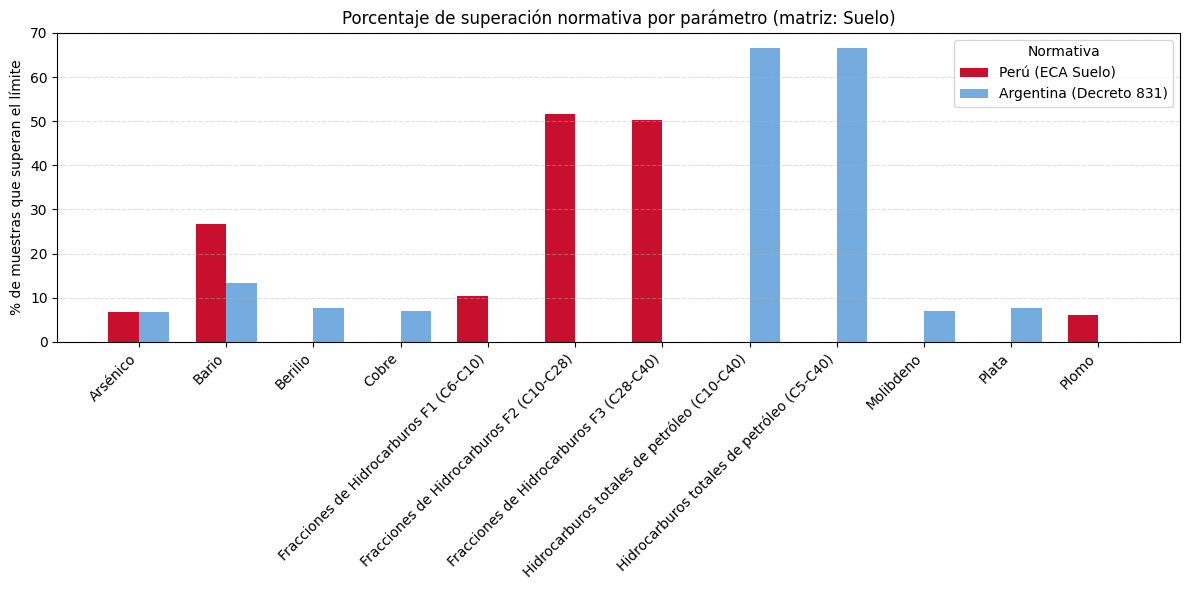

In [26]:
# 5.5 Gráfico de barras — % de superación por parámetro

resumen_graf = resumen[resumen['n_supera'] > 0].copy()

parametros = sorted(resumen_graf['Parámetro'].unique())
normativas = ['Perú (ECA Suelo)', 'Argentina (Decreto 831)']
colores    = {'Perú (ECA Suelo)': '#C8102E', 'Argentina (Decreto 831)': '#74ACDF'}

x = np.arange(len(parametros))
ancho = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
for i, norm in enumerate(normativas):
    valores = []
    for p in parametros:
        fila = resumen_graf[(resumen_graf['Parámetro'] == p) & (resumen_graf['normativa'] == norm)]
        valores.append(fila['%_superacion'].values[0] if len(fila) else 0)
    ax.bar(x + (i - 0.5) * ancho, valores, width=ancho, label=norm, color=colores[norm])

ax.set_xticks(x)
ax.set_xticklabels(parametros, rotation=45, ha='right')
ax.set_ylabel('% de muestras que superan el límite')
ax.set_title('Porcentaje de superación normativa por parámetro (matriz: Suelo)')
ax.legend(title='Normativa')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## 5.2 Comparación para AGUA

In [27]:
# Agua
# Filtra los datos para solo HTP

agua_htp = agua[agua['Parámetro'].str.contains('Hidrocarburos Totales de Petróleo', case=False)]

agua_htp.head()

,Número de informe,Nombre de la Evaluación,Etapa,Componente ambiental,Procedencia de la Muestra,Procedencia Especifica de la Muestra,Nombre del punto,Este,Norte,Altitud,...,Datum,Descripción de ubicación,Tipo de muestra,Tipo de análisis,Fecha,Hora,Valor,Parámetro,Unidad de medida,Valor_num
18,INFORME N° 00055-2019-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Segundo monitoreo,Agua,Agua natural superficial,Agua superficial de río,F01861-AG01,601347,9506175,76,...,WGS84,Punto ubicado en el río Tigre a 9 m de la oril...,Simple,Ensayo por cromatografía - HTP,1/14/19,5:54:00 PM,<0.0008,Hidrocarburos totales de petróleo (C8-C40),mg/L,0.00040
70,INFORME N° 00055-2019-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Segundo monitoreo,Agua,Agua natural superficial,Agua superficial de río,F01861-AG02,601300,9506293,76,...,WGS84,Punto ubicado en el río Tigre a 15 m de la ori...,Simple,Ensayo por cromatografía - HTP,1/14/19,5:27:00 PM,<0.0008,Hidrocarburos totales de petróleo (C8-C40),mg/L,0.00040
122,INFORME N° 00055-2019-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Segundo monitoreo,Agua,Agua natural superficial,Agua superficial de río,F01861-AG03,601399,9506003,76,...,WGS84,Punto ubicado en el río Tigre a 20 m de la ori...,Simple,Ensayo por cromatografía - HTP,1/14/19,6:19:00 PM,<0.0008,Hidrocarburos totales de petróleo (C8-C40),mg/L,0.00040
173,INFORME N° 00580-2019-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Primer monitoreo,Agua,Agua salina,Agua de mar,F05898_AG01,468461,9507737,0,...,WGS 84,Muestra puntual de agua de mar tomada a 4m en ...,Simple,Ensayo por cromatografía - HTP,6/10/2019,8:59:00 AM,<0.001980,Hidrocarburos Totales de Petróleo (Fracción ar...,mg/L,0.00099
214,INFORME N° 00580-2019-OEFA/DEAM-SSIM,Identificación de Pasivo Ambiental del Subsect...,Primer monitoreo,Agua,Agua salina,Agua de mar,F05898_AG02,468462,9507741,0,...,WGS 84,Muestra puntual de agua de mar tomada a 6m en ...,Simple,Ensayo por cromatografía - HTP,6/10/2019,9:21:00 AM,<0.001980,Hidrocarburos Totales de Petróleo (Fracción ar...,mg/L,0.00099


In [29]:
# 5.2a Comparación de AGUA (HTP) con la Normativa Peruana (ECA Agua)

# El filtro anterior ya incluye todas las variantes de nombre
# del parámetro (p. ej. "Hidrocarburos totales de petróleo (C8-C40)",
# "(C5-C40)", etc.) porque todas corresponden al mismo contaminante: HTP.

norm_peru.columns = norm_peru.columns.str.strip()
norm_peru_agua_htp = norm_peru[
    (norm_peru['matriz'].str.lower() == 'agua') &
    (norm_peru['parametro'].str.contains('Hidrocarburos Totales de Petr', case=False))
]
limite_peru_htp = norm_peru_agua_htp['valor'].iloc[0]

agua_htp = agua_htp.copy()
agua_htp['limite_peru'] = limite_peru_htp
agua_htp['supera_peru'] = agua_htp['Valor_num'] > agua_htp['limite_peru']

print(f"Límite ECA Agua - Perú (HTP): {limite_peru_htp} mg/L")
print(f"Registros que superan el ECA Agua (Perú): {int(agua_htp['supera_peru'].sum())} de {len(agua_htp)}")
agua_htp[['Nombre del punto','Parámetro','Valor_num','limite_peru','supera_peru']].head(10)

Límite ECA Agua - Perú (HTP): 0.01 mg/L
Registros que superan el ECA Agua (Perú): 7 de 20


,Nombre del punto,Parámetro,Valor_num,limite_peru,supera_peru
18,F01861-AG01,Hidrocarburos totales de petróleo (C8-C40),0.00040,0.01,False
70,F01861-AG02,Hidrocarburos totales de petróleo (C8-C40),0.00040,0.01,False
122,F01861-AG03,Hidrocarburos totales de petróleo (C8-C40),0.00040,0.01,False
173,F05898_AG01,Hidrocarburos Totales de Petróleo (Fracción ar...,0.00099,0.01,False
214,F05898_AG02,Hidrocarburos Totales de Petróleo (Fracción ar...,0.00099,0.01,False
266,F05689-AG01,Hidrocarburos totales de petróleo (C8-C40),0.00040,0.01,False
327,F05689-AG02,Hidrocarburos totales de petróleo (C8-C40),0.00040,0.01,False
397,F05689-AG03,Hidrocarburos totales de petróleo (C8-C40),0.80070,0.01,True
462,F05689-AG04,Hidrocarburos totales de petróleo (C8-C40),0.00040,0.01,False
527,F05689-AG05,Hidrocarburos totales de petróleo (C8-C40),0.00040,0.01,False


In [30]:
# 5.2b Comparación de AGUA (HTP) con la Normativa Argentina (Decreto 831)

# Ambas normativas expresan el límite de HTP en mg/L, igual que la base
# IPASH de agua, por lo que no se requiere ninguna conversión de unidades.

norm_arg_agua_htp = norm_arg[
    (norm_arg['matriz'].str.lower() == 'agua') &
    (norm_arg['parametro'].str.lower() == 'htp total')
]
limite_arg_htp = norm_arg_agua_htp['valor'].iloc[0]

agua_htp['limite_arg'] = limite_arg_htp
agua_htp['supera_arg'] = agua_htp['Valor_num'] > agua_htp['limite_arg']

print(f"Límite Argentina - Referencia de Calidad de Agua (HTP): {limite_arg_htp} mg/L")
print(f"Registros que superan el nivel guía (Argentina): {int(agua_htp['supera_arg'].sum())} de {len(agua_htp)}")
agua_htp[['Nombre del punto','Parámetro','Valor_num','limite_arg','supera_arg']].head(10)


Límite Argentina - Referencia de Calidad de Agua (HTP): 10.0 mg/L
Registros que superan el nivel guía (Argentina): 3 de 20


,Nombre del punto,Parámetro,Valor_num,limite_arg,supera_arg
18,F01861-AG01,Hidrocarburos totales de petróleo (C8-C40),0.00040,10.0,False
70,F01861-AG02,Hidrocarburos totales de petróleo (C8-C40),0.00040,10.0,False
122,F01861-AG03,Hidrocarburos totales de petróleo (C8-C40),0.00040,10.0,False
173,F05898_AG01,Hidrocarburos Totales de Petróleo (Fracción ar...,0.00099,10.0,False
214,F05898_AG02,Hidrocarburos Totales de Petróleo (Fracción ar...,0.00099,10.0,False
266,F05689-AG01,Hidrocarburos totales de petróleo (C8-C40),0.00040,10.0,False
327,F05689-AG02,Hidrocarburos totales de petróleo (C8-C40),0.00040,10.0,False
397,F05689-AG03,Hidrocarburos totales de petróleo (C8-C40),0.80070,10.0,False
462,F05689-AG04,Hidrocarburos totales de petróleo (C8-C40),0.00040,10.0,False
527,F05689-AG05,Hidrocarburos totales de petróleo (C8-C40),0.00040,10.0,False


## 5.3 Cálculo de excedencias — Agua (HTP)

Igual que para suelo, se arma una tabla consolidada en formato largo: cada fila es una
comparación entre un valor medido de HTP y un límite normativo (Perú o Argentina).


In [31]:
# 5.3 Tabla consolidada de excedencias — Agua (HTP)

cols_base_agua = ['Número de informe','Nombre del punto','Fecha','Hora','Este','Norte','Zona']

directas_peru_agua = agua_htp[cols_base_agua + ['Parámetro','Valor_num','limite_peru','supera_peru']].copy()
directas_peru_agua = directas_peru_agua.rename(columns={'Valor_num':'valor','limite_peru':'limite','supera_peru':'supera'})
directas_peru_agua['normativa'] = 'Perú (ECA Agua)'

directas_arg_agua = agua_htp[cols_base_agua + ['Parámetro','Valor_num','limite_arg','supera_arg']].copy()
directas_arg_agua = directas_arg_agua.rename(columns={'Valor_num':'valor','limite_arg':'limite','supera_arg':'supera'})
directas_arg_agua['normativa'] = 'Argentina (Decreto 831)'

excedencias_agua = pd.concat([directas_peru_agua, directas_arg_agua], ignore_index=True)
excedencias_agua['matriz'] = 'Agua'

print(f"Total de comparaciones realizadas (Agua, HTP): {len(excedencias_agua)}")
print(f"Total de excedencias detectadas: {int(excedencias_agua['supera'].sum())}")
excedencias_agua.head(10)


Total de comparaciones realizadas (Agua, HTP): 40
Total de excedencias detectadas: 10


,Número de informe,Nombre del punto,Fecha,Hora,Este,Norte,Zona,Parámetro,valor,limite,supera,normativa,matriz
0,INFORME N° 00055-2019-OEFA/DEAM-SSIM,F01861-AG01,1/14/19,5:54:00 PM,601347,9506175,18,Hidrocarburos totales de petróleo (C8-C40),0.00040,0.01,False,Perú (ECA Agua),Agua
1,INFORME N° 00055-2019-OEFA/DEAM-SSIM,F01861-AG02,1/14/19,5:27:00 PM,601300,9506293,18,Hidrocarburos totales de petróleo (C8-C40),0.00040,0.01,False,Perú (ECA Agua),Agua
2,INFORME N° 00055-2019-OEFA/DEAM-SSIM,F01861-AG03,1/14/19,6:19:00 PM,601399,9506003,18,Hidrocarburos totales de petróleo (C8-C40),0.00040,0.01,False,Perú (ECA Agua),Agua
3,INFORME N° 00580-2019-OEFA/DEAM-SSIM,F05898_AG01,6/10/2019,8:59:00 AM,468461,9507737,17,Hidrocarburos Totales de Petróleo (Fracción ar...,0.00099,0.01,False,Perú (ECA Agua),Agua
4,INFORME N° 00580-2019-OEFA/DEAM-SSIM,F05898_AG02,6/10/2019,9:21:00 AM,468462,9507741,17,Hidrocarburos Totales de Petróleo (Fracción ar...,0.00099,0.01,False,Perú (ECA Agua),Agua
5,INFORME N° 00632-2019-OEFA/DEAM-SSIM,F05689-AG01,17/3/2019,11:48:00 AM,178313,9521077,18,Hidrocarburos totales de petróleo (C8-C40),0.00040,0.01,False,Perú (ECA Agua),Agua
6,INFORME N° 00632-2019-OEFA/DEAM-SSIM,F05689-AG02,17/3/2019,12:21:00 PM,178328,9521072,18,Hidrocarburos totales de petróleo (C8-C40),0.00040,0.01,False,Perú (ECA Agua),Agua
7,INFORME N° 00632-2019-OEFA/DEAM-SSIM,F05689-AG03,17/3/2019,1:09:00 PM,178490,9521148,18,Hidrocarburos totales de petróleo (C8-C40),0.80070,0.01,True,Perú (ECA Agua),Agua
8,INFORME N° 00632-2019-OEFA/DEAM-SSIM,F05689-AG04,17/3/2019,1:31:00 PM,178690,9521262,18,Hidrocarburos totales de petróleo (C8-C40),0.00040,0.01,False,Perú (ECA Agua),Agua
9,INFORME N° 00632-2019-OEFA/DEAM-SSIM,F05689-AG05,17/3/2019,1:46:00 PM,178707,9521351,18,Hidrocarburos totales de petróleo (C8-C40),0.00040,0.01,False,Perú (ECA Agua),Agua


## 5.4 Porcentaje de superación por parámetro y matriz — Agua (HTP)


In [32]:
# 5.4 Porcentaje de superación por parámetro y matriz — Agua (HTP)

resumen_agua = (excedencias_agua
                .groupby(['matriz','normativa','Parámetro'])
                .agg(n_muestras=('supera','size'), n_supera=('supera','sum'))
                .reset_index())
resumen_agua['%_superacion'] = (resumen_agua['n_supera'] / resumen_agua['n_muestras'] * 100).round(1)
resumen_agua = resumen_agua.sort_values('%_superacion', ascending=False).reset_index(drop=True)

resumen_agua


,matriz,normativa,Parámetro,n_muestras,n_supera,%_superacion
0,Agua,Perú (ECA Agua),Hidrocarburos totales de petróleo (C6-C28),5,5,100.0
1,Agua,Argentina (Decreto 831),Hidrocarburos totales de petróleo (C6-C28),5,3,60.0
2,Agua,Perú (ECA Agua),Hidrocarburos totales de petróleo (C8-C40),11,2,18.2
3,Agua,Argentina (Decreto 831),Hidrocarburos Totales de Petróleo (Fracción ar...,2,0,0.0
4,Agua,Argentina (Decreto 831),Hidrocarburos totales de petróleo (C8-C40),11,0,0.0
5,Agua,Argentina (Decreto 831),Hidrocarburos totales de petróleo (C10-C40),2,0,0.0
6,Agua,Perú (ECA Agua),Hidrocarburos totales de petróleo (C10-C40),2,0,0.0
7,Agua,Perú (ECA Agua),Hidrocarburos Totales de Petróleo (Fracción ar...,2,0,0.0


## 5.5 Mapa interactivo de contaminantes que superan la normativa — Agua (HTP)

Se seleccionan los puntos de muestreo de agua donde el HTP supera la Normativa Peruana
y/o la Argentina. Se reutiliza la función `utm_to_latlon` definida en la sección de Suelo
para convertir las coordenadas UTM a latitud/longitud.


In [33]:
# 5.5 Selección de puntos con excedencia y mapa folium — Agua (HTP)

agua_htp['lat'], agua_htp['lon'] = utm_to_latlon(agua_htp['Este'].values, agua_htp['Norte'].values,
                                                  agua_htp['Zona'].values, hemisphere='S')

puntos_excedidos_agua = excedencias_agua[excedencias_agua['supera']].copy()
puntos_excedidos_agua = puntos_excedidos_agua.merge(
    agua_htp[cols_base_agua + ['lat','lon']].drop_duplicates(),
    on=cols_base_agua, how='left'
)

resumen_puntos_agua = []
for (nombre, lat, lon), grupo in puntos_excedidos_agua.groupby(['Nombre del punto','lat','lon']):
    detalle = '<br>'.join(
        f"- {r['Parámetro']} &gt; {r['normativa']} (valor={r['valor']:.4f}, límite={r['limite']:.4f})"
        for _, r in grupo.iterrows()
    )
    resumen_puntos_agua.append({
        'Nombre del punto': nombre, 'lat': lat, 'lon': lon,
        'n_excedencias': len(grupo),
        'detalle': detalle,
        'supera_peru': (grupo['normativa'] == 'Perú (ECA Agua)').any(),
        'supera_arg':  (grupo['normativa'] == 'Argentina (Decreto 831)').any(),
    })
resumen_puntos_agua = pd.DataFrame(resumen_puntos_agua)

print(f"Puntos de muestreo de agua con excedencia de HTP: {len(resumen_puntos_agua)} de "
      f"{agua_htp[cols_base_agua].drop_duplicates().shape[0]} puntos analizados")

mapa_agua_htp = folium.Map(
    location=[agua_htp['lat'].mean(), agua_htp['lon'].mean()],
    zoom_start=8, tiles='CartoDB positron'
)

for _, row in resumen_puntos_agua.iterrows():
    if row['supera_peru'] and row['supera_arg']:
        color = 'red'      # supera ambas normativas
    elif row['supera_peru']:
        color = 'orange'   # supera solo Perú
    else:
        color = 'purple'   # supera solo Argentina

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=6 + min(row['n_excedencias'], 8),
        color=color, fill=True, fill_color=color, fill_opacity=0.75,
        popup=folium.Popup(
            f"<b>{row['Nombre del punto']}</b><br>{row['n_excedencias']} excedencia(s)<br>{row['detalle']}",
            max_width=350
        ),
        tooltip=row['Nombre del punto']
    ).add_to(mapa_agua_htp)

leyenda_html_agua = '''
<div style="position: fixed; bottom: 30px; left: 30px; z-index:9999; background:white;
            padding:10px; border:2px solid grey; border-radius:6px; font-size:13px;">
<b>HTP excede:</b><br>
<span style="color:orange;">&#9679;</span> Solo Normativa Perú<br>
<span style="color:purple;">&#9679;</span> Solo Normativa Argentina<br>
<span style="color:red;">&#9679;</span> Ambas normativas
</div>
'''
mapa_agua_htp.get_root().html.add_child(folium.Element(leyenda_html_agua))

mapa_agua_htp


Puntos de muestreo de agua con excedencia de HTP: 7 de 20 puntos analizados


## 5.6 Gráfico de barras: % de superación — Agua (HTP)


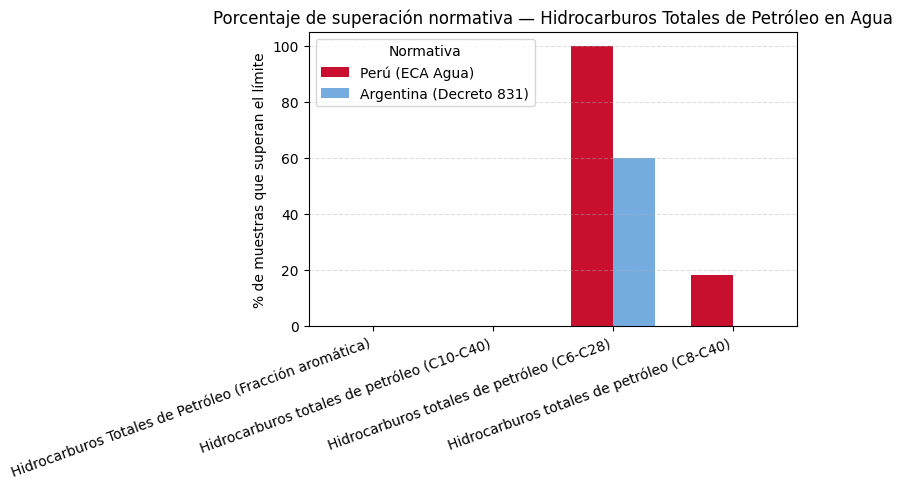

In [35]:
# 5.6 Gráfico de barras — % de superación (Agua, HTP)

parametros_agua = sorted(resumen_agua['Parámetro'].unique())
normativas_agua = ['Perú (ECA Agua)', 'Argentina (Decreto 831)']
colores_agua    = {'Perú (ECA Agua)': '#C8102E', 'Argentina (Decreto 831)': '#74ACDF'}

x = np.arange(len(parametros_agua))
ancho = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
for i, norm in enumerate(normativas_agua):
    valores = []
    for p in parametros_agua:
        fila = resumen_agua[(resumen_agua['Parámetro'] == p) & (resumen_agua['normativa'] == norm)]
        valores.append(fila['%_superacion'].values[0] if len(fila) else 0)
    ax.bar(x + (i - 0.5) * ancho, valores, width=ancho, label=norm, color=colores_agua[norm])

ax.set_xticks(x)
ax.set_xticklabels(parametros_agua, rotation=20, ha='right')
ax.set_ylabel('% de muestras que superan el límite')
ax.set_title('Porcentaje de superación normativa — Hidrocarburos Totales de Petróleo en Agua')
ax.legend(title='Normativa')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
